## Project 1: AI-Driven Citizen Grievance & Sentiment Analysis
## Week 1 — Data Cleaning, Text Preprocessing & EDA


## Step 1: Install & Import Libraries

In [3]:
# Run this cell once to install required libraries
!pip install nltk spacy wordcloud matplotlib seaborn pandas scikit-learn
!python -m spacy download en_core_web_sm

   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
    --------------------------------------- 0.3/14.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.2 MB 1.3 MB/s eta 0:00:11
   -- ------------------------------------- 0.8/14.2 MB 1.3 MB/s eta 0:00:11
   -- ------------------------------------- 1.0/14.2 MB 1.3 MB/s eta 0:00:11
   --- ------------------------------------ 1.3/14.2 MB 1.3 MB/s eta 0:00:10
   ---- ----------------------------------- 1.6/14.2 MB 1.3 MB/s eta 0:00:10
   ----- ---------------------------------- 1.8/14.2 MB 1.3 MB/s eta 0:00:10
   ----- ---------------------------------- 2.1/14.2 MB 1.3 MB/s eta 0:00:10
   ------ --------------------------------- 2.4/14.2 MB 1.3 MB/s eta 0:00:10
   ------- -------------------------------- 2.6/14.2 MB 1.3 MB/s eta 0:00:09
   -------- ------------------------------- 3.1/14.2 MB 1.3 MB/s eta 0:00:09
   --------- ------------------------------ 3.4/14.2 MB 1.3 MB/s eta 0:00:09
   ----------

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from collections import Counter

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print(' All libraries loaded successfully!')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HCORP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HCORP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HCORP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


 All libraries loaded successfully!


---
## Step 2: Load Dataset

> **Note:** Download the NYC 311 dataset from Kaggle and upload it to Colab, OR use the synthetic data generator below.

In [25]:
df = pd.read_csv('complaints_processed.csv')
print(f' Data loaded successfully! Shape: {df.shape}')

 Data loaded successfully! Shape: (162421, 3)


---
## Step 3: Exploratory Data Analysis (EDA)

In [44]:
# Basic info
print('=== First 5 Rows ===')
print(df.head())
print('=== Dataset Info ===')
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Duplicate Rows ===')
print(df.duplicated().sum())

=== First 5 Rows ===
   Unnamed: 0           product  \
0           0       credit_card   
1           1       credit_card   
2           2    retail_banking   
3           3  credit_reporting   
4           4  credit_reporting   

                                           narrative  text_length  word_count  
0  purchase order day shipping amount receive pro...         1705         230  
1  forwarded message date tue subject please inve...          904         132  
2  forwarded message cc sent friday pdt subject f...         1230         173  
3  payment history missing credit report speciali...          903         131  
4  payment history missing credit report made mis...          851         123  
=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Unnamed: 0   162421 non-null  int64 
 1   product      162421 non-nu

In [29]:
# Fill categorical/text columns 
df['narrative'] = df['narrative'].fillna(df['narrative'].mode()[0])

# Verify no missing values remain
print("\nMissing values after filling:")
print(df.isnull().sum())


Missing values after filling:
Unnamed: 0    0
product       0
narrative     0
dtype: int64


=== Text Length Stats ===
         text_length     word_count
count  162421.000000  162421.000000
mean      588.515180      80.229890
std       830.956002     108.869492
min         3.000000       1.000000
25%       192.000000      27.000000
50%       361.000000      50.000000
75%       683.000000      95.000000
max     20596.000000    2685.000000


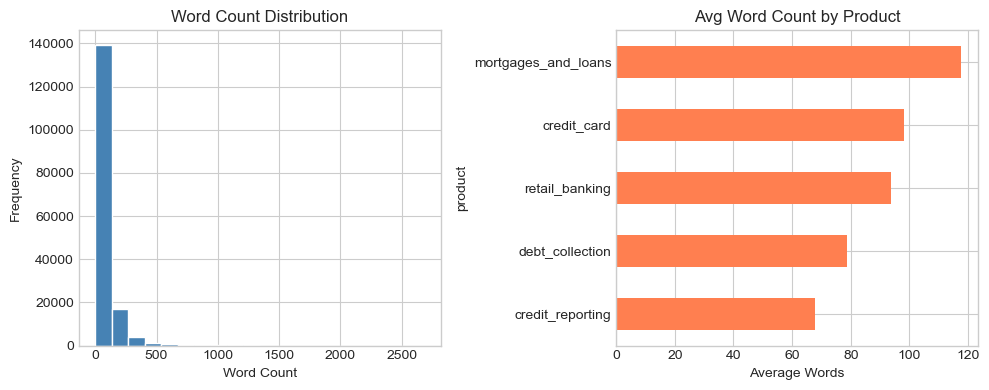

In [30]:
# Complaint text length analysis

df['text_length'] = df['narrative'].fillna('').apply(len)
df['word_count'] = df['narrative'].fillna('').apply(lambda x: len(x.split()))

print('=== Text Length Stats ===')
print(df[['text_length', 'word_count']].describe())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['word_count'], bins=20, color='steelblue', edgecolor='white')
plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df.groupby('product')['word_count'].mean().sort_values().plot(kind='barh', color='coral')
plt.title('Avg Word Count by Product')
plt.xlabel('Average Words')

plt.tight_layout()
plt.savefig('eda_text_length.png', dpi=150, bbox_inches='tight')
plt.show()


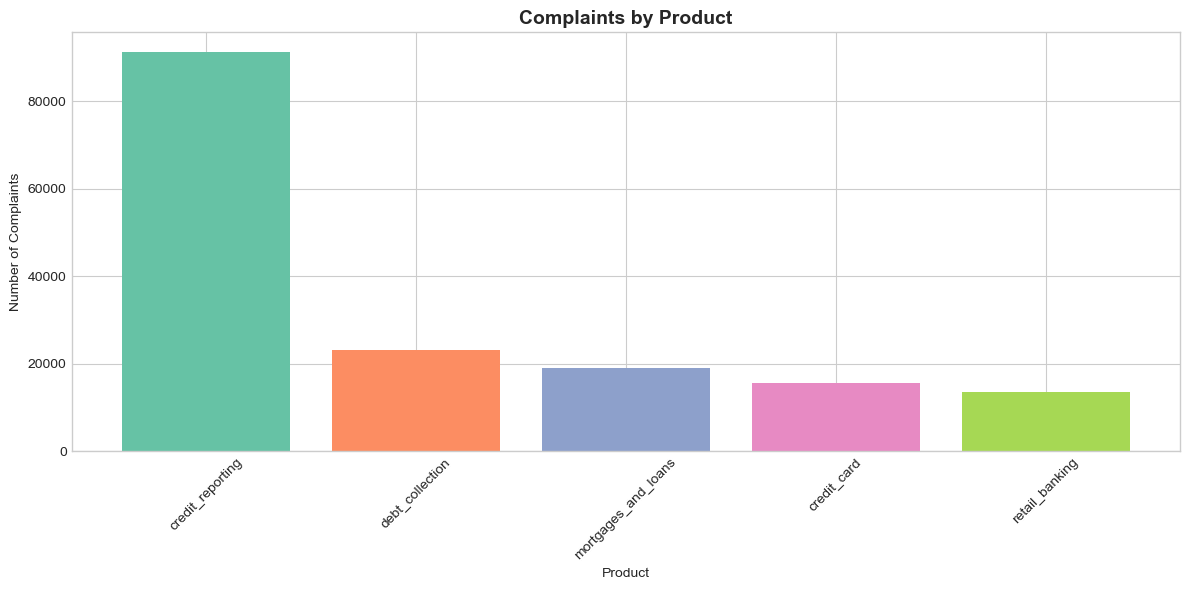

EDA chart saved!


In [45]:
fig, ax = plt.subplots(figsize=(12, 6))

# Product count
dept_counts = df['product'].value_counts()

# Bar plot
ax.bar(dept_counts.index, dept_counts.values,
       color=sns.color_palette('Set2'))

ax.set_title('Complaints by Product', fontsize=14, fontweight='bold')
ax.set_xlabel('Product')
ax.set_ylabel('Number of Complaints')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA chart saved!")

In [65]:
## Step 4: Text Preprocessing

In [57]:
import re
import spacy
from nltk.corpus import stopwords
from tqdm import tqdm

# Load spaCy faster
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

STOPWORDS = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Clean text
df["cleaned_text"] = df["narrative"].fillna("").apply(clean_text)

# Fast lemmatization using nlp.pipe
processed_texts = []

for doc in tqdm(nlp.pipe(df["cleaned_text"], batch_size=1000), total=len(df)):
    tokens = [
        token.lemma_
        for token in doc
        if token.text not in STOPWORDS
        and len(token.text) > 2
    ]
    processed_texts.append(" ".join(tokens))

df["processed_text"] = processed_texts

100%|██████████| 162421/162421 [17:38<00:00, 153.44it/s] 


In [59]:
# Verify preprocessing results
# Verify preprocessing results
df[['narrative', 'cleaned_text', 'processed_text']].head(5)

,narrative,cleaned_text,processed_text
0,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...
1,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...,forward message date tue subject please invest...
2,forwarded message cc sent friday pdt subject f...,forwarded message cc sent friday pdt subject f...,forward message send friday pdt subject final ...
3,payment history missing credit report speciali...,payment history missing credit report speciali...,payment history miss credit report specialized...
4,payment history missing credit report made mis...,payment history missing credit report made mis...,payment history miss credit report make mistak...


In [73]:

## Step 5: Word Cloud Visualization

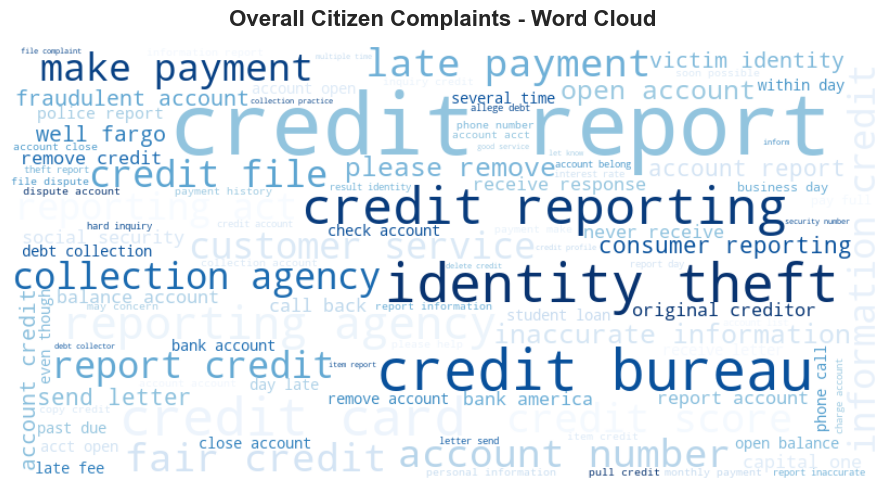

✅ Saved: overall_citizen_complaints_-_word_cloud.png


KeyError: 'department'

In [ ]:
def generate_wordcloud(text_series, title, colormap='Blues'):
    all_text = ' '.join(text_series.dropna())
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colormap,
        max_words=100
    ).generate(all_text)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold', pad=15)
    plt.tight_layout()
    filename = title.lower().replace(' ', '_') + '.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {filename}')

# Overall word cloud
generate_wordcloud(df['processed_text'], 'Overall Citizen Complaints - Word Cloud', 'Blues')

# Per-department word clouds
colormaps = ['Reds', 'Greens', 'Oranges', 'Purples', 'YlOrBr']
for dept, cmap in zip(df['product'].unique(), colormaps):
    subset = df[df['product'] == dept]['processed_text']
    generate_wordcloud(subset, f'{dept} - Word Cloud', cmap)